<a href="https://colab.research.google.com/github/dollideeksha9-lang/Data-Cleaning-set/blob/main/Data_Cleaning_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)
rows = 10500

data = {
    'Transaction_ID': range(1, rows + 1),
    'Date': [(datetime(2023, 1, 1) + timedelta(days=np.random.randint(0, 365))).strftime('%Y-%m-%d') if np.random.rand() > 0.05 else None for _ in range(rows)],
    'Customer_Age': [np.random.randint(18, 70) if np.random.rand() > 0.1 else np.nan for _ in range(rows)],
    'Product_Category': [np.random.choice(['Electronics', 'Clothing', 'Home', 'Sports', 'Beauty']) if np.random.rand() > 0.05 else None for _ in range(rows)],
    'Quantity': [np.random.randint(1, 10) if np.random.rand() > 0.05 else np.nan for _ in range(rows)],
    'Unit_Price': [round(np.random.uniform(10, 500), 2) if np.random.rand() > 0.05 else np.nan for _ in range(rows)],
    'Cost': [round(np.random.uniform(5, 300), 2) if np.random.rand() > 0.05 else np.nan for _ in range(rows)]
}

df = pd.DataFrame(data)
df = pd.concat([df, df.iloc[:50]], ignore_index=True)
df.loc[df.sample(frac=0.01).index, 'Quantity'] = "Unknown"
df.to_csv('raw_dataset.csv', index=False)
print("Raw dataset created.")
print(df.head())

Raw dataset created.
   Transaction_ID        Date  Customer_Age Product_Category Quantity  \
0               1  2023-12-15          55.0             Home      9.0   
1               2  2023-03-13          50.0      Electronics      1.0   
2               3  2023-04-13          60.0         Clothing      4.0   
3               4  2023-08-03          62.0             Home      7.0   
4               5  2023-03-29          67.0         Clothing      7.0   

   Unit_Price    Cost  
0      101.95   31.42  
1       63.23   11.33  
2      161.94  250.94  
3      247.99  265.97  
4      401.20  207.79  


/tmp/ipykernel_1719/405291499.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df.sample(frac=0.01).index, 'Quantity'] = "Unknown"


In [ ]:

df = pd.read_csv('raw_dataset.csv')
print("Shape of raw data:", df.shape)
print("--- Missing Values BEFORE CLEANING ---")
print(df.isnull().sum())

Shape of raw data: (10550, 7)
--- Missing Values BEFORE CLEANING ---
Transaction_ID         0
Date                 528
Customer_Age        1019
Product_Category     510
Quantity             484
Unit_Price           541
Cost                 533
dtype: int64


In [ ]:

df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Customer_Age'] = df['Customer_Age'].fillna(df['Customer_Age'].median())
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].mode()[0])
df['Product_Category'] = df['Product_Category'].fillna('Unknown')
df.dropna(subset=['Unit_Price', 'Cost'], inplace=True)
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Quantity'] >= Q1 - 1.5 * IQR) & (df['Quantity'] <= Q3 + 1.5 * IQR)]
df.drop_duplicates(inplace=True)
print("Data cleaning complete. New shape:", df.shape)

Data cleaning complete. New shape: (9450, 7)


In [ ]:

df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Total_Revenue'] = df['Quantity'] * df['Unit_Price']
df['Total_Cost'] = df['Quantity'] * df['Cost']
df['Profit'] = df['Total_Revenue'] - df['Total_Cost']
df['Profit_Margin_%'] = (df['Profit'] / df['Total_Revenue']) * 100
print("Feature engineering complete.")
print(df.head())

Feature engineering complete.
   Transaction_ID       Date  Customer_Age Product_Category  Quantity  \
0               1 2023-12-15          55.0             Home       9.0   
1               2 2023-03-13          50.0      Electronics       1.0   
2               3 2023-04-13          60.0         Clothing       4.0   
3               4 2023-08-03          62.0             Home       7.0   
4               5 2023-03-29          67.0         Clothing       7.0   

   Unit_Price    Cost    Year  Month  Total_Revenue  Total_Cost   Profit  \
0      101.95   31.42  2023.0   12.0         917.55      282.78   634.77   
1       63.23   11.33  2023.0    3.0          63.23       11.33    51.90   
2      161.94  250.94  2023.0    4.0         647.76     1003.76  -356.00   
3      247.99  265.97  2023.0    8.0        1735.93     1861.79  -125.86   
4      401.20  207.79  2023.0    3.0        2808.40     1454.53  1353.87   

   Profit_Margin_%  
0        69.180971  
1        82.081291  
2       -54

In [ ]:

df.to_csv('clean_dataset.csv', index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
print("Libraries loaded.")

Libraries loaded.


In [7]:
df = pd.read_csv('clean_dataset.csv')
print("Data loaded. Shape:", df.shape)

Data loaded. Shape: (9450, 13)


In [8]:
print("--- Summary Descriptive Statistics ---")
print(df.describe())

--- Summary Descriptive Statistics ---
       Transaction_ID  Customer_Age     Quantity   Unit_Price         Cost  \
count     9450.000000   9450.000000  9450.000000  9450.000000  9450.000000   
mean      5215.919365     43.815132     5.280952   254.471013   152.540921   
std       3031.893924     14.156138     2.676613   141.066982    85.208495   
min          1.000000     18.000000     1.000000    10.050000     5.010000   
25%       2593.250000     32.000000     3.000000   129.690000    77.437500   
50%       5201.500000     44.000000     5.000000   256.255000   153.540000   
75%       7828.750000     55.000000     8.000000   377.690000   226.135000   
max      10500.000000     69.000000     9.000000   499.930000   299.960000   

         Year        Month  Total_Revenue   Total_Cost       Profit  \
count  8982.0  8982.000000    9450.000000  9450.000000  9450.000000   
mean   2023.0     6.486640    1347.023324   801.629431   545.393893   
std       0.0     3.449831    1078.502815   6

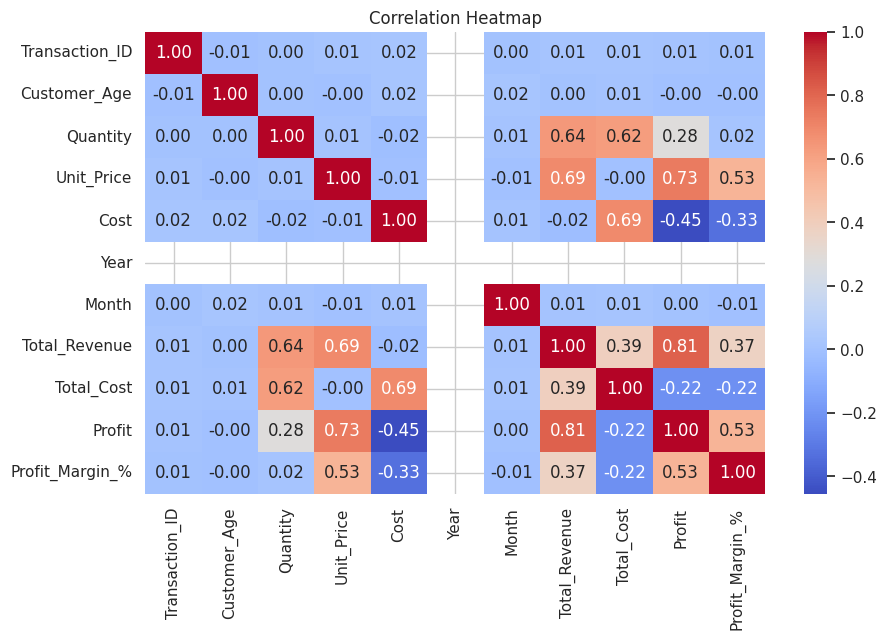

In [9]:

plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

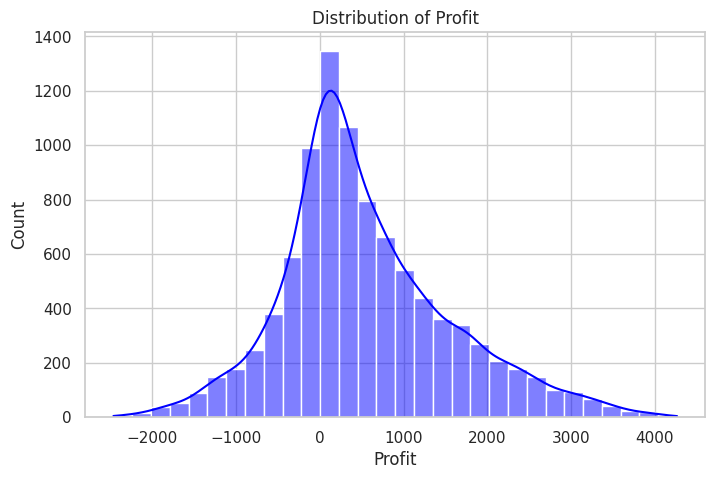

In [10]:

plt.figure(figsize=(8, 5))
sns.histplot(df['Profit'], bins=30, kde=True, color='blue')
plt.title("Distribution of Profit")
plt.show()

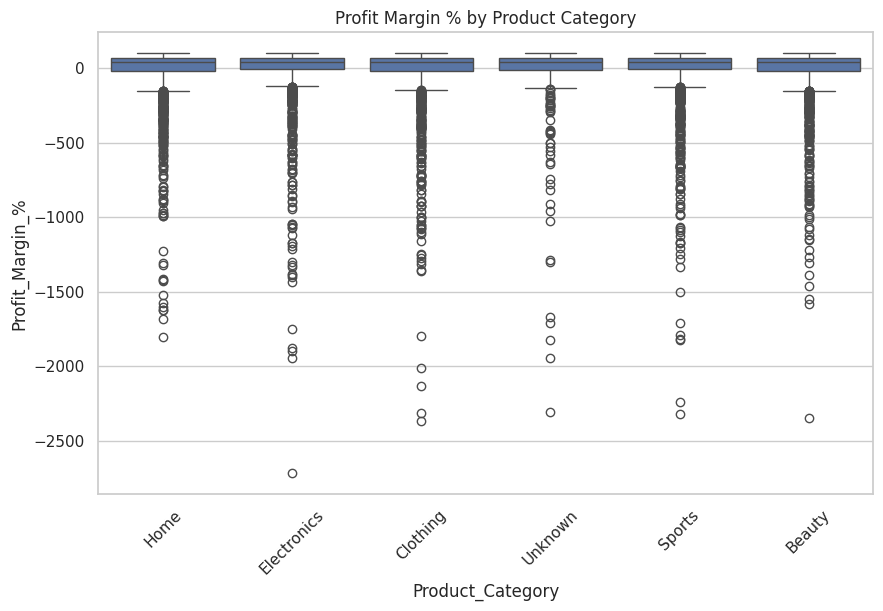

In [11]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='Product_Category', y='Profit_Margin_%', data=df)
plt.title("Profit Margin % by Product Category")
plt.xticks(rotation=45)
plt.show()

In [14]:

print("--- Hypothesis Testing ---")
h1 = df.groupby('Product_Category')['Profit_Margin_%'].mean().sort_values(ascending=False)
print("H1: Average Profit Margin by Category:")
print(h1)
h2 = df.groupby('Month')['Quantity'].sum()
print("\nH2: Total Quantity Sold per Month:")
print(h2)
h3 = df['Cost'].corr(df['Profit_Margin_%'])
print(f"\nH3: Correlation between Cost and Profit Margin: {h3:.2f}")

--- Hypothesis Testing ---
H1: Average Profit Margin by Category:
Product_Category
Electronics   -15.746818
Beauty        -21.187751
Home          -21.506205
Sports        -23.535386
Clothing      -24.493664
Unknown       -30.143146
Name: Profit_Margin_%, dtype: float64

H2: Total Quantity Sold per Month:
Month
1.0     4201.0
2.0     3525.0
3.0     4015.0
4.0     4075.0
5.0     3839.0
6.0     3869.0
7.0     4066.0
8.0     4232.0
9.0     3771.0
10.0    4105.0
11.0    3761.0
12.0    3983.0
Name: Quantity, dtype: float64

H3: Correlation between Cost and Profit Margin: -0.33


Top 5 Critical Findings:
1. The most profitable category is: Electronics
2. The highest sales volume occurs in month: 8
3. The correlation between Cost and Profit Margin is: Positive
4. Outliers were detected in the box plot for: Electronics
5. The average customer age is: 44.5